In [1]:
import sys
sys.path.append('../')

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sounddevice
import numpy as np
import IPython.display as ipd 
import matplotlib.pyplot as plt

from src.core.speech.data import log_mel_spectrogram
from src.core.speech import config as conf


# Sounddevice

In [6]:
inp = sounddevice.InputStream(
    samplerate=conf.SAMPLING_RATE,
    blocksize=conf.STREAM_CHUNK_SAMPLES,
    channels=1  # Mono only
)

## Making Sure the Mic Works Fine

In [7]:
seq = np.array([])
inp.start()
for i in range(5):
    X, _ = inp.read(int(0.250 * conf.SAMPLING_RATE))
    seq = np.concat([seq, X[:, 0]])
inp.stop()

ipd.display(ipd.Audio(seq, rate=conf.SAMPLING_RATE))

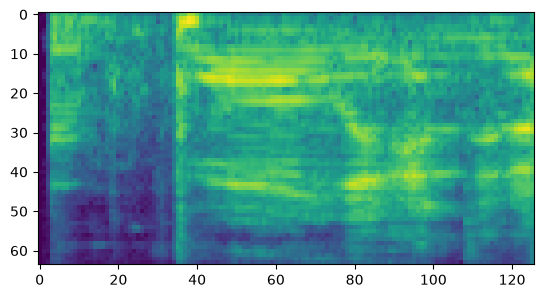

In [8]:
plt.imshow(log_mel_spectrogram(seq, conf.SAMPLING_RATE))

### Finding a Good Frame Count

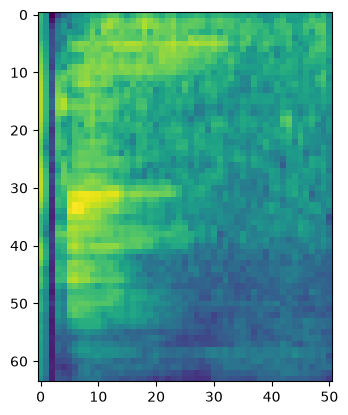

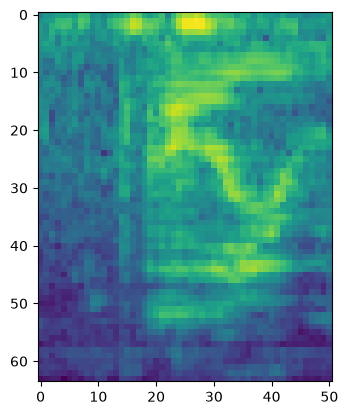

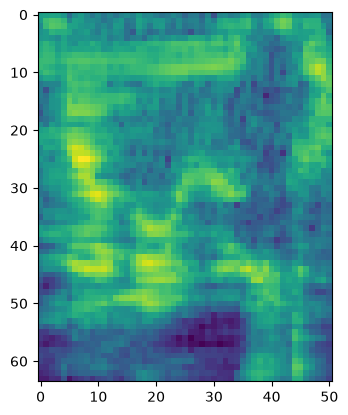

In [9]:
inp.start()
seq = np.array([])
for i in range(3):
    X, _ = inp.read(8_000)
    plt.imshow(log_mel_spectrogram(X[:,0], conf.SAMPLING_RATE))
    plt.show()
inp.stop()